In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet

In [8]:
# Прогнозирование временных рядов (ts)
# 1. Загрузка и очистка данных
# 2. Визуализауция и декомпозиция ts
# 3. Генерация признаков
# 4. Обучение модели линейной регрессии
# 5. Библиотека Prophet

In [43]:
df = pd.read_csv('../data/raw/airline-passengers.csv')

In [44]:
df.head(3)

,month,total_passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   month             144 non-null    object
 1   total_passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [46]:
df['month'] = pd.to_datetime(df['month'])

In [47]:
df = df.set_index('month')

In [48]:
df.head(3)

,total_passengers
month,
1949-01-01,112
1949-02-01,118
1949-03-01,132


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   total_passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


<Axes: xlabel='month'>

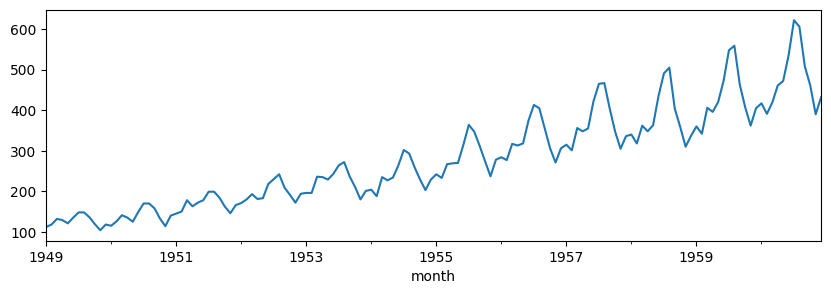

In [50]:
df['total_passengers'].plot(figsize=(10,3))

In [51]:
help(seasonal_decompose)

Help on function seasonal_decompose in module statsmodels.tsa.seasonal:

seasonal_decompose(x, model='additive', filt=None, period=None, two_sided=True, extrapolate_trend=0)
    Seasonal decomposition using moving averages.
    
    Parameters
    ----------
    x : array_like
        Time series. If 2d, individual series are in columns. x must contain 2
        complete cycles.
    model : {"additive", "multiplicative"}, optional
        Type of seasonal component. Abbreviations are accepted.
    filt : array_like, optional
        The filter coefficients for filtering out the seasonal component.
        The concrete moving average method used in filtering is determined by
        two_sided.
    period : int, optional
        Period of the series (e.g., 1 for annual, 4 for quarterly, etc). Must
        be used if x is not a pandas object or if the index of x does not have
        a frequency. Overrides default periodicity of x if x is a pandas
        object with a timeseries index.
 

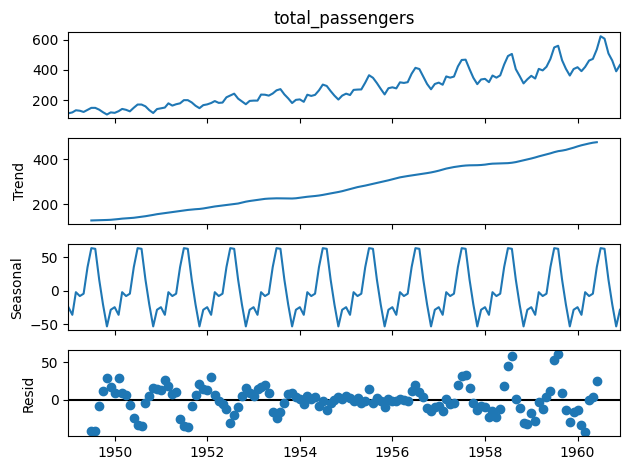

In [27]:
result = seasonal_decompose(df['total_passengers'], period=12, model='additive')
fig = result.plot()
plt.show()

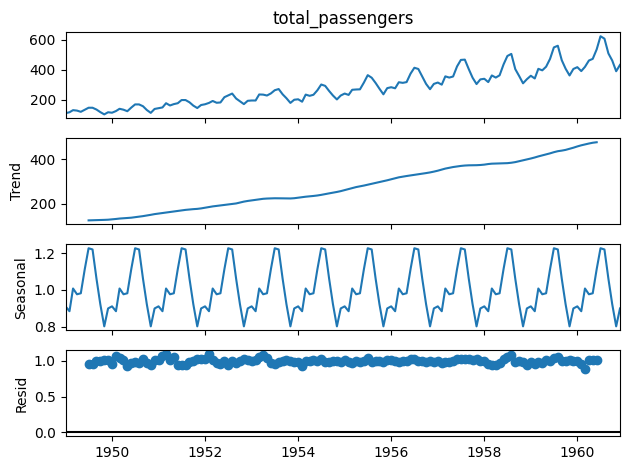

In [28]:
result = seasonal_decompose(df['total_passengers'], period=12, model='multiplicative')
fig = result.plot()
plt.show()

In [29]:
df_lr = df.copy()

In [30]:
df_lr['month'] = df_lr.index.month

In [37]:
# df_lr['lag_1'] = df_lr['total_passengers'].shift(1)

In [35]:
for i in range(1, 4):
    df_lr[f'lag_{i}'] = df_lr['total_passengers'].shift(i)

In [42]:
df_lr['rolling_6_mean'] = df_lr['total_passengers'].shift(1).rolling(6).mean()

In [52]:
df_lr

,total_passengers,month,lag_1,lag_2,lag_3,rolling_6_mean
month,,,,,,
1949-01-01,112,1,NaN,NaN,NaN,NaN
1949-02-01,118,2,112.0,NaN,NaN,NaN
1949-03-01,132,3,118.0,112.0,NaN,NaN
1949-04-01,129,4,132.0,118.0,112.0,NaN
1949-05-01,121,5,129.0,132.0,118.0,NaN
...,...,...,...,...,...,...
1960-08-01,606,8,622.0,535.0,472.0,483.333333
1960-09-01,508,9,606.0,622.0,535.0,519.166667
1960-10-01,461,10,508.0,606.0,622.0,534.000000


In [54]:
df_lr = df_lr.dropna()

In [58]:
test_size = 12
train = df_lr[:-test_size]
test = df_lr[-test_size:]

In [61]:
test

,total_passengers,month,lag_1,lag_2,lag_3,rolling_6_mean
month,,,,,,
1960-01-01,417,1,405.0,362.0,407.0,457.333333
1960-02-01,391,2,417.0,405.0,362.0,435.500000
1960-03-01,419,3,391.0,417.0,405.0,407.500000
1960-04-01,461,4,419.0,391.0,417.0,400.166667
1960-05-01,472,5,461.0,419.0,391.0,409.166667
1960-06-01,535,6,472.0,461.0,419.0,427.500000
1960-07-01,622,7,535.0,472.0,461.0,449.166667
1960-08-01,606,8,622.0,535.0,472.0,483.333333
1960-09-01,508,9,606.0,622.0,535.0,519.166667


In [62]:
y_train = train['total_passengers']
X_train = train.drop('total_passengers', axis=1)

y_test = test['total_passengers']
X_test = test.drop('total_passengers', axis=1)

In [63]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
predictions = model.predict(X_test)
n = X_train.shape[0]
k = X_train.shape[1]
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)
r2_adj = 1-(1-r2)*(n-1)/(n-k)
print(f'n = {n}')
print(f'k = {k}')
print(f'mae = {mae:.2f}')
print(f'mse = {mse:.2f}')
print(f'rmse = {rmse:.2f}')
print(f'R^2 = {r2:.3f}')
print(f'R^2_adj = {r2_adj:.3f}')

n = 126
k = 5
mae = 40.01
mse = 2192.82
rmse = 46.83
R^2 = 0.604
R^2_adj = 0.591


In [67]:
predictions

array([446.47563588, 434.59243474, 384.79168226, 426.96486693,
       467.48126345, 463.97695249, 537.59114669, 620.58988512,
       566.71491835, 457.18658778, 450.14409032, 390.35373211])

In [83]:
pred = pd.DataFrame(predictions, test.index, columns=['total_passengers'])

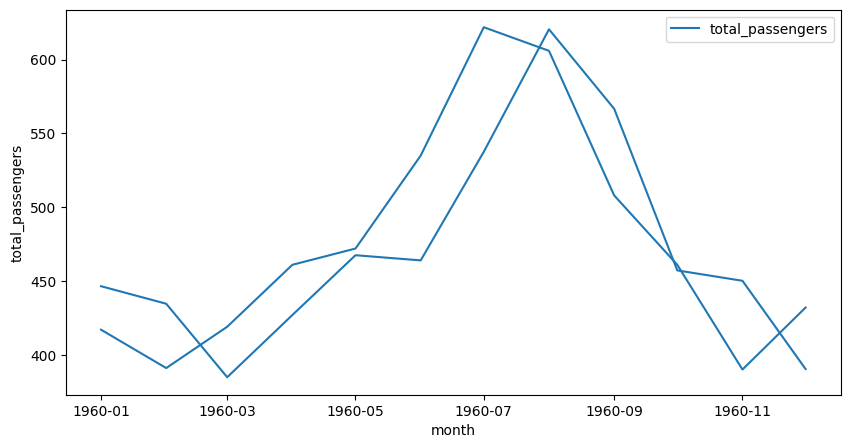

In [86]:
plt.figure(figsize=(10,5)) # Размер рисунка
plt.title('') # Заголовок
sns.lineplot(y_test)
sns.lineplot(pred)
plt.show() # Показать график

In [87]:
df_prophet = df.reset_index()

In [88]:
df_prophet

,month,total_passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [89]:
df_prophet.columns = ['ds', 'y']

In [95]:
df_prophet

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [92]:
test_size = 12
train = df_prophet[:-test_size]
test = df_prophet[-test_size:]

In [93]:
model_prophet = Prophet(seasonality_mode='multiplicative')
model_prophet.fit(train)

10:56:57 - cmdstanpy - INFO - Chain [1] start processing
10:56:58 - cmdstanpy - INFO - Chain [1] done processing


In [94]:
future = model_prophet.make_future_dataframe(periods=12, freq='MS')

In [98]:
forecast = model_prophet.predict(future)

In [99]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,1949-01-01,114.691042,89.968563,115.135887,114.691042,114.691042,-0.100455,-0.100455,-0.100455,-0.100455,-0.100455,-0.100455,0.0,0.0,0.0,103.169705
1,1949-02-01,116.436010,86.347386,111.958279,116.436010,116.436010,-0.150642,-0.150642,-0.150642,-0.150642,-0.150642,-0.150642,0.0,0.0,0.0,98.895886
2,1949-03-01,118.012110,105.524033,132.003787,118.012110,118.012110,0.002384,0.002384,0.002384,0.002384,0.002384,0.002384,0.0,0.0,0.0,118.293500
3,1949-04-01,119.757078,102.653340,128.571233,119.757078,119.757078,-0.033658,-0.033658,-0.033658,-0.033658,-0.033658,-0.033658,0.0,0.0,0.0,115.726243
4,1949-05-01,121.445756,105.542630,130.409772,121.445756,121.445756,-0.026159,-0.026159,-0.026159,-0.026159,-0.026159,-0.026159,0.0,0.0,0.0,118.268800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,1960-08-01,465.104945,560.722196,585.833168,464.322444,465.840604,0.232482,0.232482,0.232482,0.232482,0.232482,0.232482,0.0,0.0,0.0,573.233300
140,1960-09-01,467.914954,483.797826,509.585481,466.945252,468.800024,0.061144,0.061144,0.061144,0.061144,0.061144,0.061144,0.0,0.0,0.0,496.525013
141,1960-10-01,470.634317,420.043275,445.934586,469.466118,471.696737,-0.079314,-0.079314,-0.079314,-0.079314,-0.079314,-0.079314,0.0,0.0,0.0,433.306270
142,1960-11-01,473.444325,366.060985,392.492303,472.077114,474.660141,-0.197939,-0.197939,-0.197939,-0.197939,-0.197939,-0.197939,0.0,0.0,0.0,379.730999


C:\Users\Администратор\AppData\Local\Temp\ipykernel_10656\1412012672.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


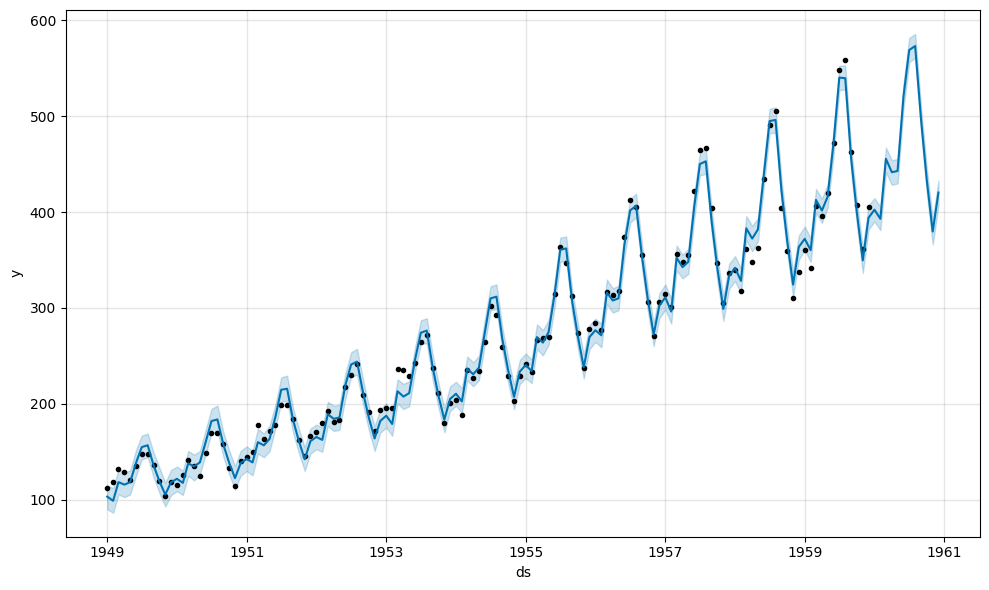

In [101]:
fig = model_prophet.plot(forecast)
fig.show()

In [108]:
y_test

month
1960-01-01    417
1960-02-01    391
1960-03-01    419
1960-04-01    461
1960-05-01    472
1960-06-01    535
1960-07-01    622
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: total_passengers, dtype: int64

In [118]:
predictions = forecast.iloc[-12:]['yhat']

In [119]:
predictions

132    402.445018
133    392.948490
134    455.584216
135    441.584031
136    442.918309
137    520.585208
138    569.037583
139    573.233300
140    496.525013
141    433.306270
142    379.730999
143    420.384456
Name: yhat, dtype: float64

In [121]:
predictions = forecast.iloc[-12:]['yhat']
n = X_train.shape[0]
k = X_train.shape[1]
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)
r2_adj = 1-(1-r2)*(n-1)/(n-k)
print(f'n = {n}')
print(f'k = {k}')
print(f'mae = {mae:.2f}')
print(f'mse = {mse:.2f}')
print(f'rmse = {rmse:.2f}')
print(f'R^2 = {r2:.3f}')
print(f'R^2_adj = {r2_adj:.3f}')

n = 126
k = 5
mae = 21.90
mse = 666.85
rmse = 25.82
R^2 = 0.880
R^2_adj = 0.876
